# 05 — Risk Categorization & Prioritization Table
**Project:** GB Compound Hazards Risk Prioritization  
**Course:** Artificial Intelligence in Human Water Systems  

---
## Objectives
- Classify each compound hazard event into risk levels (High / Medium / Low)
- Use a wind intensity × precipitation intensity risk matrix
- Aggregate results by NUTS1 region
- Build the final decision-maker prioritization table
- Answer the research question:

> *For the regions in Great Britain that have experienced extreme compound-risk events, which categorizations could decision-makers define to prioritize the allocation of resources?*


## 1. Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

print('Libraries loaded successfully!')

Libraries loaded successfully!


## 2. Load Compound Hazard Database

In [2]:
compound_db = pd.read_parquet('../data/processed/compound_hazards_db.parquet')

# Filter to GB regions only
compound_db = compound_db[compound_db['nuts1_region'] != 'Outside GB'].copy()

print(f'Compound events loaded: {len(compound_db):,}')
print(f'Regions: {compound_db["nuts1_region"].nunique()}')
print(compound_db.head(3).to_string())

Compound events loaded: 73
Regions: 1
   compound_id  rain_cluster_id  wind_cluster_id      compound_start        compound_end  compound_duration_h  compound_extent_km2  peak_precipitation_mm  peak_wind_ms  mean_precipitation_mm  mean_wind_ms  rain_duration_h  wind_duration_h  lat_min  lat_max  lon_min  lon_max  lat_centroid  lon_centroid  year season        nuts1_region
1            1                9                0 2019-09-04 09:00:00 2019-09-05 09:00:00                 24.0           42839.0625               4.001548     26.652459               2.190477     20.391398              7.0             23.0  49.2500  49.5625  -6.5000  -5.3125      49.40625      -5.90625  2019    SON  South West England
2            2               10                0 2019-09-04 10:00:00 2019-09-05 09:00:00                 23.0            2705.6250               3.541518     26.652459               2.009547     20.391398              2.0             23.0  49.6875  49.8125  -6.4375  -6.2500      49.75000  

## 3. Normalize Intensity Values

Following Tilloy et al. (2022), we express intensity as empirical cumulative probability [0, 1] so that wind and precipitation are comparable on the same scale.

In [3]:
def empirical_cdf(series):
    """Convert values to empirical cumulative probability [0, 1]."""
    ranks = series.rank(method='average')
    return ranks / (len(series) + 1)


compound_db['wind_intensity_norm'] = empirical_cdf(compound_db['peak_wind_ms'])
compound_db['rain_intensity_norm'] = empirical_cdf(compound_db['peak_precipitation_mm'])

print('Normalized intensity ranges:')
print(f'  Wind:          {compound_db["wind_intensity_norm"].min():.3f} — {compound_db["wind_intensity_norm"].max():.3f}')
print(f'  Precipitation: {compound_db["rain_intensity_norm"].min():.3f} — {compound_db["rain_intensity_norm"].max():.3f}')

Normalized intensity ranges:
  Wind:          0.014 — 0.986
  Precipitation: 0.014 — 0.986


## 4. Risk Classification — Wind × Precipitation Matrix

We classify each compound event using a 3×3 risk matrix:

```
              WIND INTENSITY
              Low      Medium   High
         ┌────────┬────────┬────────┐
P  Low   │  Low   │  Low   │ Medium │
R        ├────────┼────────┼────────┤
E  Med   │  Low   │ Medium │  High  │
C        ├────────┼────────┼────────┤
I  High  │ Medium │  High  │  High  │
P        └────────┴────────┴────────┘
```

In [4]:
def classify_intensity(value, low_threshold=0.33, high_threshold=0.66):
    """Classify normalized intensity into Low / Medium / High."""
    if value < low_threshold:
        return 'Low'
    elif value < high_threshold:
        return 'Medium'
    else:
        return 'High'


# Risk matrix lookup
RISK_MATRIX = {
    ('Low',    'Low'):    'Low',
    ('Low',    'Medium'): 'Low',
    ('Low',    'High'):   'Medium',
    ('Medium', 'Low'):    'Low',
    ('Medium', 'Medium'): 'Medium',
    ('Medium', 'High'):   'High',
    ('High',   'Low'):    'Medium',
    ('High',   'Medium'): 'High',
    ('High',   'High'):   'High',
}


compound_db['rain_class']  = compound_db['rain_intensity_norm'].apply(classify_intensity)
compound_db['wind_class']  = compound_db['wind_intensity_norm'].apply(classify_intensity)
compound_db['risk_level']  = compound_db.apply(
    lambda row: RISK_MATRIX[(row['rain_class'], row['wind_class'])], axis=1
)

print('Risk level distribution:')
print(compound_db['risk_level'].value_counts().to_string())
print(f'\nTotal events: {len(compound_db):,}')

Risk level distribution:
risk_level
High      25
Medium    25
Low       23

Total events: 73


## 5. Visualize Risk Matrix

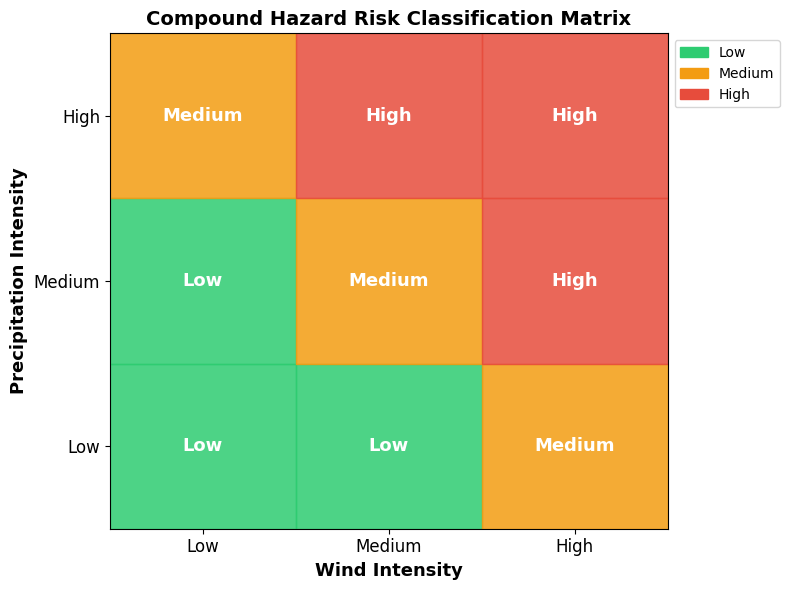

In [5]:
fig, ax = plt.subplots(figsize=(8, 6))

color_map = {'Low': '#2ecc71', 'Medium': '#f39c12', 'High': '#e74c3c'}
categories = ['Low', 'Medium', 'High']

for i, rain_cat in enumerate(categories):
    for j, wind_cat in enumerate(categories):
        risk = RISK_MATRIX[(rain_cat, wind_cat)]
        color = color_map[risk]
        rect = plt.Rectangle([j, i], 1, 1, color=color, alpha=0.85)
        ax.add_patch(rect)
        ax.text(j + 0.5, i + 0.5, risk, ha='center', va='center',
                fontsize=13, fontweight='bold', color='white')

ax.set_xlim(0, 3)
ax.set_ylim(0, 3)
ax.set_xticks([0.5, 1.5, 2.5])
ax.set_yticks([0.5, 1.5, 2.5])
ax.set_xticklabels(categories, fontsize=12)
ax.set_yticklabels(categories, fontsize=12)
ax.set_xlabel('Wind Intensity', fontsize=13, fontweight='bold')
ax.set_ylabel('Precipitation Intensity', fontsize=13, fontweight='bold')
ax.set_title('Compound Hazard Risk Classification Matrix', fontsize=14, fontweight='bold')

patches = [mpatches.Patch(color=v, label=k) for k, v in color_map.items()]
ax.legend(handles=patches, loc='upper left', bbox_to_anchor=(1, 1))

plt.tight_layout()
plt.savefig('../outputs/figures/05_risk_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Aggregate by NUTS1 Region

In [6]:
risk_order = {'High': 3, 'Medium': 2, 'Low': 1}

region_summary = compound_db.groupby('nuts1_region').agg(
    total_events         = ('compound_id', 'count'),
    high_risk_events     = ('risk_level', lambda x: (x == 'High').sum()),
    medium_risk_events   = ('risk_level', lambda x: (x == 'Medium').sum()),
    low_risk_events      = ('risk_level', lambda x: (x == 'Low').sum()),
    avg_duration_h       = ('compound_duration_h', 'mean'),
    avg_extent_km2       = ('compound_extent_km2', 'mean'),
    avg_peak_wind_ms     = ('peak_wind_ms', 'mean'),
    avg_peak_rain_mm     = ('peak_precipitation_mm', 'mean'),
    max_peak_wind_ms     = ('peak_wind_ms', 'max'),
    max_peak_rain_mm     = ('peak_precipitation_mm', 'max'),
).reset_index()

# Dominant risk level per region
dominant_risk = compound_db.groupby('nuts1_region')['risk_level'].agg(
    lambda x: x.value_counts().index[0]
).reset_index()
dominant_risk.columns = ['nuts1_region', 'dominant_risk']

region_summary = region_summary.merge(dominant_risk, on='nuts1_region')

# Sort by dominant risk then total events
region_summary['risk_score'] = region_summary['dominant_risk'].map(risk_order)
region_summary = region_summary.sort_values(
    ['risk_score', 'high_risk_events'], ascending=[False, False]
).drop('risk_score', axis=1).reset_index(drop=True)

print('Region summary:')
print(region_summary.to_string(index=False))

Region summary:
      nuts1_region  total_events  high_risk_events  medium_risk_events  low_risk_events  avg_duration_h  avg_extent_km2  avg_peak_wind_ms  avg_peak_rain_mm  max_peak_wind_ms  max_peak_rain_mm dominant_risk
South West England            73                25                  25               23       16.643836    35043.403253         24.125346          4.669095         36.565775         10.607719          High


## 7. Final Decision-Maker Prioritization Table

In [7]:
priority_table = region_summary[[
    'nuts1_region',
    'total_events',
    'high_risk_events',
    'avg_duration_h',
    'avg_peak_wind_ms',
    'avg_peak_rain_mm',
    'avg_extent_km2',
    'dominant_risk'
]].copy()

priority_table.columns = [
    'Region (NUTS1)',
    'Total Compound Events',
    'High Risk Events',
    'Avg Duration (h)',
    'Avg Peak Wind (m/s)',
    'Avg Peak Rain (mm)',
    'Avg Spatial Extent (km²)',
    'Priority Level'
]

priority_table['Avg Duration (h)'] = priority_table['Avg Duration (h)'].round(1)
priority_table['Avg Peak Wind (m/s)'] = priority_table['Avg Peak Wind (m/s)'].round(2)
priority_table['Avg Peak Rain (mm)'] = priority_table['Avg Peak Rain (mm)'].round(2)
priority_table['Avg Spatial Extent (km²)'] = priority_table['Avg Spatial Extent (km²)'].round(0).astype(int)

print('\n' + '='*90)
print('COMPOUND HAZARD RISK PRIORITIZATION TABLE — Great Britain (2009–2019)')
print('='*90)
print(priority_table.to_string(index=False))
print('='*90)
print('Priority Level: High = immediate resource allocation | Medium = planned investment | Low = monitoring')


COMPOUND HAZARD RISK PRIORITIZATION TABLE — Great Britain (2009–2019)
    Region (NUTS1)  Total Compound Events  High Risk Events  Avg Duration (h)  Avg Peak Wind (m/s)  Avg Peak Rain (mm)  Avg Spatial Extent (km²) Priority Level
South West England                     73                25              16.6                24.13                4.67                     35043           High
Priority Level: High = immediate resource allocation | Medium = planned investment | Low = monitoring


## 8. Visualize Prioritization Table

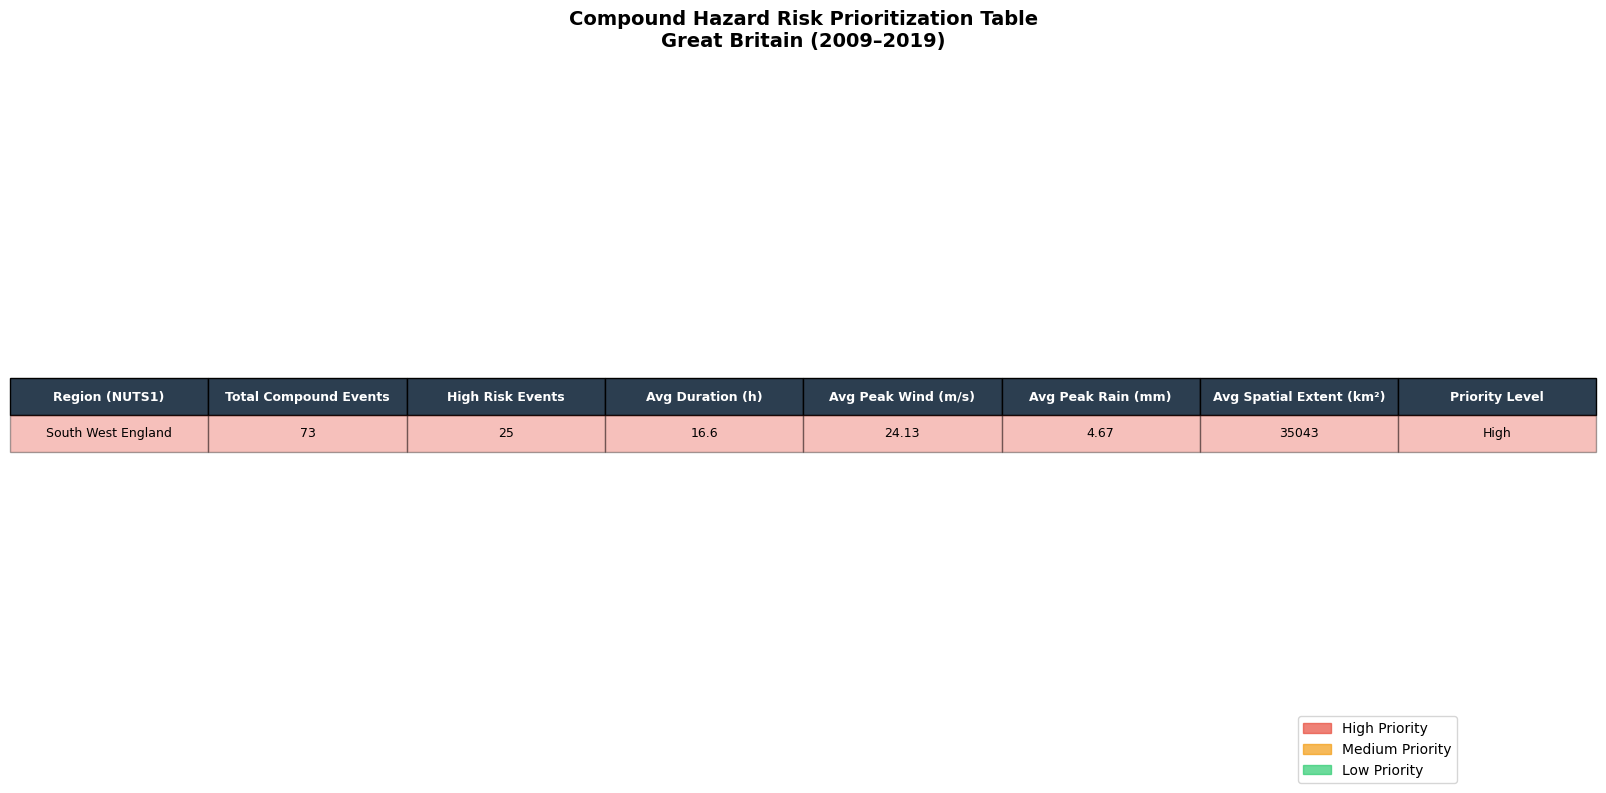

In [8]:
color_map = {'High': '#e74c3c', 'Medium': '#f39c12', 'Low': '#2ecc71'}
row_colors = priority_table['Priority Level'].map(color_map).values

fig, ax = plt.subplots(figsize=(16, 8))
ax.axis('off')

table_data = priority_table.values.tolist()
col_labels = list(priority_table.columns)

table = ax.table(
    cellText=table_data,
    colLabels=col_labels,
    loc='center',
    cellLoc='center'
)

table.auto_set_font_size(False)
table.set_fontsize(9)
table.scale(1.2, 2)

# Color header
for j in range(len(col_labels)):
    table[0, j].set_facecolor('#2c3e50')
    table[0, j].set_text_props(color='white', fontweight='bold')

# Color rows by priority
for i, color in enumerate(row_colors):
    for j in range(len(col_labels)):
        table[i+1, j].set_facecolor(color)
        table[i+1, j].set_alpha(0.35)

ax.set_title(
    'Compound Hazard Risk Prioritization Table\nGreat Britain (2009–2019)',
    fontsize=14, fontweight='bold', pad=20
)

patches = [mpatches.Patch(color=color_map[k], alpha=0.7, label=f'{k} Priority') for k in ['High', 'Medium', 'Low']]
ax.legend(handles=patches, loc='lower right', bbox_to_anchor=(1, -0.05))

plt.tight_layout()
plt.savefig('../outputs/figures/05_prioritization_table.png', dpi=150, bbox_inches='tight')
plt.show()

## 9. Temporal Trend — Risk Level per Year

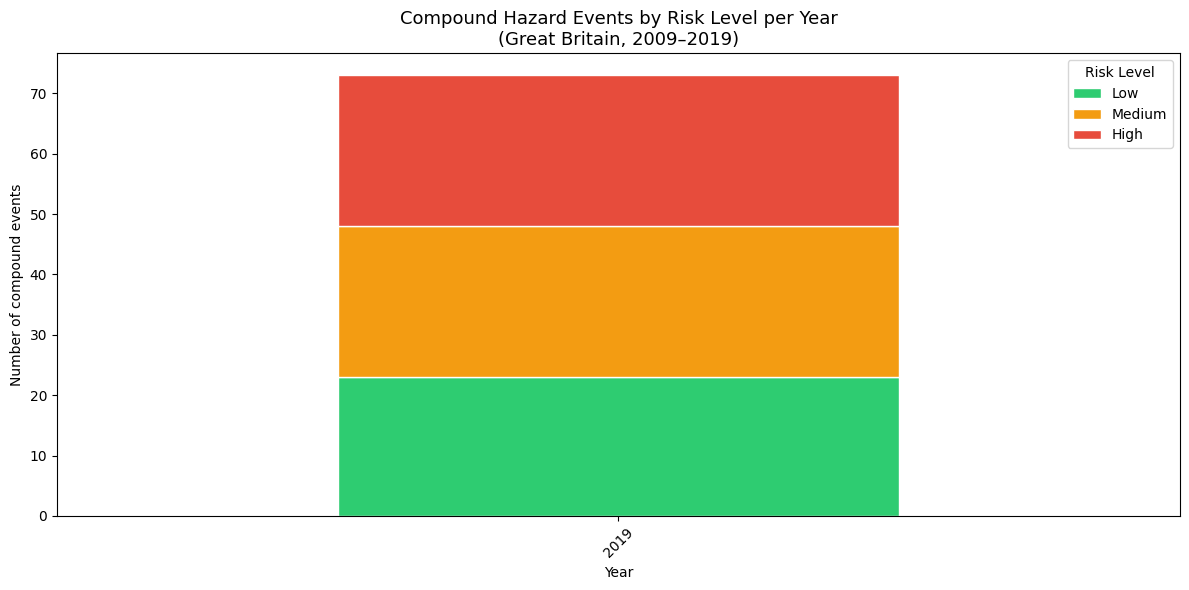

In [9]:
yearly_risk = compound_db.groupby(['year', 'risk_level']).size().unstack(fill_value=0)

# Ensure all columns exist
for level in ['Low', 'Medium', 'High']:
    if level not in yearly_risk.columns:
        yearly_risk[level] = 0

yearly_risk = yearly_risk[['Low', 'Medium', 'High']]

fig, ax = plt.subplots(figsize=(12, 6))
yearly_risk.plot(
    kind='bar', stacked=True, ax=ax,
    color=['#2ecc71', '#f39c12', '#e74c3c'],
    edgecolor='white'
)

ax.set_title('Compound Hazard Events by Risk Level per Year\n(Great Britain, 2009–2019)', fontsize=13)
ax.set_xlabel('Year')
ax.set_ylabel('Number of compound events')
ax.tick_params(axis='x', rotation=45)
ax.legend(title='Risk Level')

plt.tight_layout()
plt.savefig('../outputs/figures/05_risk_trend_per_year.png', dpi=150, bbox_inches='tight')
plt.show()

## 10. Save Final Outputs

In [10]:
# Save full compound database with risk levels
compound_db.to_csv('../outputs/reports/compound_hazards_classified.csv', index=False)

# Save prioritization table
priority_table.to_csv('../outputs/reports/prioritization_table_gb_nuts1.csv', index=False)

print('Saved:')
print('  outputs/reports/compound_hazards_classified.csv')
print('  outputs/reports/prioritization_table_gb_nuts1.csv')
print(f'\nFinal prioritization table ({len(priority_table)} regions):')
print(priority_table[['Region (NUTS1)', 'Total Compound Events', 'High Risk Events', 'Priority Level']].to_string(index=False))

Saved:
  outputs/reports/compound_hazards_classified.csv
  outputs/reports/prioritization_table_gb_nuts1.csv

Final prioritization table (1 regions):
    Region (NUTS1)  Total Compound Events  High Risk Events Priority Level
South West England                     73                25           High
